In [1]:
from faker import Faker
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import stats
import random

## **1. Création des profils d’utilisateurs**


In [2]:
df_user = pd.read_csv('users.csv')

In [3]:
df_user.head()

,user_id,name,email,password,age,preference
0,1,Alexandre Traore,patrick32@example.net,@#8P@CsS4V,31,"['Comedie', 'Action', 'Science-Fiction']"
1,2,Denis-Franck Ledoux,francois16@example.org,^5RTiSnXpU,63,['Drame']
2,3,Gabriel Roussel,dlopes@example.net,27vLXlf0^z,21,['Documentaire']
3,4,Alfred Gomes-Maréchal,christophe39@example.net,Ht3U6T7p^H,21,"['Animation', 'Action', 'Documentaire']"
4,5,André Masson,lorraineleroux@example.net,G&Rx9CmcR7,48,['Horreur']


In [4]:
df_film = pd.read_csv('films.csv')

In [5]:
df_film.head()

,movie_id,title,genre,year,duration,rating
0,1,The Shawshank Redemption,Comedie,1971,174,3
1,2,The Godfather,Horreur,1984,97,1
2,3,The Dark Knight,Documentaire,1975,155,4
3,4,Pulp Fiction,Action,1971,91,2
4,5,Forrest Gump,Horreur,2002,157,1


In [6]:
df_watch_history = pd.read_csv('watch_history.csv')
df_watch_history['date'] = pd.to_datetime(df_watch_history['date'])

In [7]:
df_watch_history.head()

,history_id,user_id,movie_id,movie_title,genre,rate,date
0,1,1,188,Akira,Romance,4,2025-02-09
1,2,1,152,Dumb and Dumber,Thriller,5,2026-01-09
2,3,1,69,True Grit,Drame,4,2026-04-20
3,4,1,83,Toy Story 3,Comedie,1,2025-05-15
4,5,1,63,Taxi Driver,Animation,3,2025-10-24


## **2. Création du moteur de recommandation :**

### **2.1 Filtrer les films en fonction des préférences de l'utilisateur.**

In [8]:
import ast

preferences = ast.literal_eval(df_user.loc[0, 'preference'])

In [9]:
def preferences_films(preferences):
    films = df_film[df_film['genre'].isin(preferences)]
    return films

# Préférences du premier utilisateur
prefs = preferences

print("Films conseillés :")
all_pref = preferences_films(prefs)

for movie in all_pref['title']:
    print(f"{movie}, ",end='')

Films conseillés :
The Shawshank Redemption, Pulp Fiction, The Matrix, The Lord of the Rings: The Two Towers, Star Wars: The Empire Strikes Back, Interstellar, Gladiator, The Lion King, Saving Private Ryan, The Wolf of Wall Street, The Hateful Eight, Avatar: The Way of Water, Terminator 2: Judgment Day, Predator, John Wick, Mission: Impossible, Top Gun, Heat, No Country for Old Men, Fargo, O Brother, Where Art Thou?, A Beautiful Mind, Good Will Hunting, La La Land, The Grand Budapest Hotel, Isle of Dogs, Toy Story, Toy Story 3, Monsters, Inc., WALL-E, Ratatouille, The Incredibles, Cars, Soul, Luca, Turning Red, Elemental, Kung Fu Panda, How to Train Your Dragon, Madagascar, Beauty and the Beast, Aladdin, Cinderella, Citizen Kane, Psycho, Rear Window, North by Northwest, 12 Angry Men, Doctor Zhivago, Rocky, The Breakfast Club, Groundhog Day, Ace Ventura: Pet Detective, The Hangover, Pretty Woman, Before Sunset, Life Is Beautiful, The Host, Howls Moving Castle, Kikis Delivery Service, Yo

* Recuperer les préférences de l'utilisateur connecté
* Créer un Dataframe qui va prendre 3 variables, le genre du film, les films et la note du film
* On va ajouter créer une fonction avec les préférences de l'utilisateur en paramètre, cette fonction va parcouris tout le dataset et va ressortir tous les films qui sont égales aux préférence de l'utilisateur

### **2.2 Classement des films en fonction des notes des utilisateurs ou des similitudes de genre**

#### **Classement selon les notes des utilisateurs**

* Utilisation de sort_values par rapport au 'rating' et comme c'est par la plus grande valeur, l'ascending = false

In [10]:
def ranking (df_film) :
    df_film_ranking = df_film.sort_values('rating',ascending=False)
    return df_film_ranking

df = ranking(df_film)
print('Voici la liste des films conseillé en fonction de la notation :')
for movie in df['title']:
    print(f"{movie}, ",end='')

Voici la liste des films conseillé en fonction de la notation :
Fight Club, Inception, Mad Max: Fury Road, Die Hard, The Prestige, Back to the Future, Saving Private Ryan, Star Wars: The Empire Strikes Back, O Brother, Where Art Thou?, Scarface, A Beautiful Mind, Avatar, Blade Runner 2049, The Breakfast Club, Rocky, Amelie, Crouching Tiger, Hidden Dragon, Slumdog Millionaire, Mrs. Doubtfire, Coming to America, Bridesmaids, Pretty Woman, Moonlight, Vertigo, Aladdin, 12 Angry Men, Gone with the Wind, Citizen Kane, Shrek, Elemental, Luca, Soul, Ratatouille, Brave, Monsters, Inc., Finding Dory, Toy Story, Toy Story 2, The Grand Budapest Hotel, Fantastic Mr. Fox, Pinocchio, Spider-Man: Into the Spider-Verse, North by Northwest, La La Land, Moana, The Dark Knight, The Big Lebowski, Casino, The Terminator, Inglourious Basterds, Raging Bull, Django Unchained, The Silence of the Lambs, The Social Network, The Departed, Star Wars: A New Hope, The Intouchables, Oldboy, Princess Mononoke, Howls Mo

#### **Classement selon la similitude de genre**

In [11]:
def similarity(genre, preferences):
    if genre in preferences:
        return 1
    return 0

def ranking_similarity(df_film, preferences, top_n=10):
    df_film_similarity = df_film.copy()
    df_film_similarity['score_similarite'] = df_film_similarity['genre'].apply(
        lambda genre: similarity(genre, preferences)
    )
    df_film_similarity = df_film_similarity.sort_values(
        by=['score_similarite', 'rating', 'year'],
        ascending=[False, False, False]
    )

    return df_film_similarity.head(top_n)[
        ['title', 'genre', 'rating', 'year', 'score_similarite']
    ]

df_similarity = ranking_similarity(df_film, prefs)

print('Préférences de l\'utilisateur :', prefs)
print('Voici le classement des films conseillés selon la similitude de genre :')
for movie in df_similarity['title']:
    print(f"{movie}, ",end='')

Préférences de l'utilisateur : ['Comedie', 'Action', 'Science-Fiction']
Voici le classement des films conseillés selon la similitude de genre :
Pretty Woman, Luca, Saving Private Ryan, Soul, Toy Story, Star Wars: The Empire Strikes Back, 12 Angry Men, Ratatouille, O Brother, Where Art Thou?, The Grand Budapest Hotel, 

**Exemple d'affichage**

In [12]:
user = df_user.loc[0]
user_see = df_watch_history[df_watch_history['user_id']==user['user_id']]

In [13]:
last_see = user_see.iloc[-1]['movie_title']

In [14]:
suggestion =  df_similarity.iloc[0]['title']

In [15]:
#Suggestion basé sur les similiarité
print(f'{user['name']}, vous avez regarder {last_see}, peut-être que vous aimeriez {suggestion}')

Alexandre Traore, vous avez regarder The Little Mermaid, peut-être que vous aimeriez Pretty Woman


In [16]:
suggestion_note =  df.iloc[0]['title']

In [17]:
#Suggestion basé sur la note
print(f'{user['name']}, vous avez regarder {last_see}, peut-être que vous aimeriez {suggestion_note}')

Alexandre Traore, vous avez regarder The Little Mermaid, peut-être que vous aimeriez Fight Club


In [18]:
suggestion_all_pref =  all_pref.iloc[0]['title']

In [19]:
#Suggestion basé sur la note
print(f'{user['name']}, vous avez regarder {last_see}, peut-être que vous aimeriez {suggestion_note}')

Alexandre Traore, vous avez regarder The Little Mermaid, peut-être que vous aimeriez Fight Club


In [21]:
user_watch_history = df_watch_history[df_watch_history['user_id'] == user['user_id']]

## **3. Analyse et visualisation des informations :**

In [22]:
user_watch_history['genre'].value_counts()

genre
Animation          2
Thriller           1
Romance            1
Drame              1
Comedie            1
Science-Fiction    1
Action             1
Name: count, dtype: int64

Historique de visionnage de l'utilisateur :


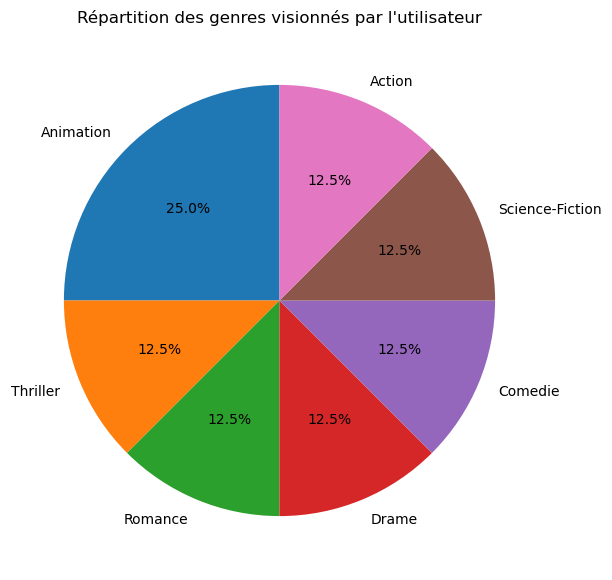

In [23]:
# Affichage de l'historique
print("Historique de visionnage de l'utilisateur :")

# 1. Répartition des genres

genre_counts = user_watch_history['genre'].value_counts()

plt.figure(figsize=(7, 7))

plt.pie(
    genre_counts,
    labels=genre_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Répartition des genres visionnés par l'utilisateur")
plt.show()

L'utilisateur a plus regarder les films d'anniamtion que les autres catégories, environ 25% de visionnage

In [24]:
df_watch_history['year'] = df_watch_history['date'].dt.year
df_watch_history['month'] = df_watch_history['date'].dt.month

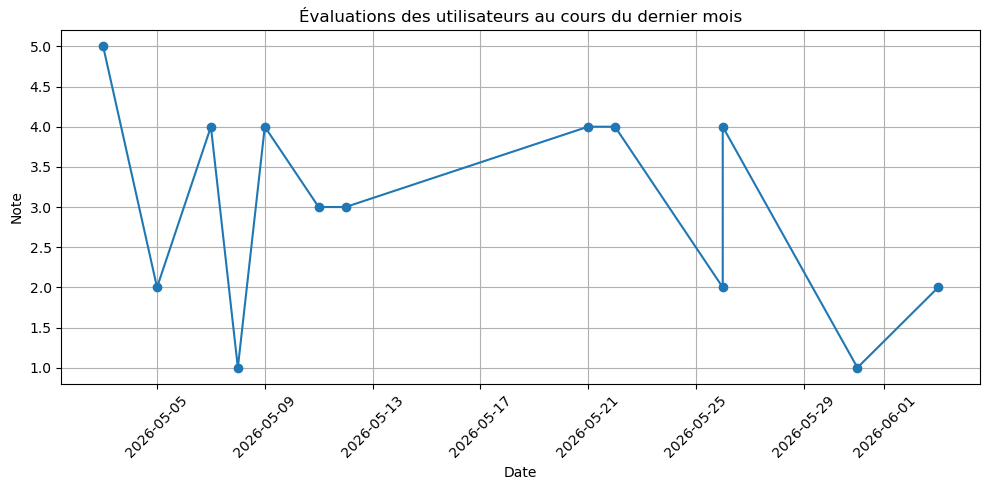

In [32]:
# Date la plus récente du dataset
last_date = df_watch_history['date'].max()

# Données du dernier mois
last_month = df_watch_history[
    df_watch_history['date'] >= last_date - pd.DateOffset(months=1)
]

# Tri par date
last_month = last_month.sort_values('date')

plt.figure(figsize=(10, 5))

plt.plot(
    last_month['date'],
    last_month['rate'],
    marker='o'
)

plt.title("Évaluations des utilisateurs au cours du dernier mois")
plt.xlabel("Date")
plt.ylabel("Note")
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

On remarque que les premiers films ont beaucoup interessé les utilisateurs, d'ou la bonne notation, plus tard, les autres films, bien qu'ils ont plu à la plus part n'ont pas eu autant de succès que les films en debut de mois